# Installing Necessary Libraries

In [1]:
!pip install graphviz pydotplus

Defaulting to user installation because normal site-packages is not writeable


# Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import graphviz
import pydotplus
from IPython.display import Image, display
from IPython.display import Latex
from collections import Counter
from sklearn.model_selection import KFold
from functools import reduce
from scipy.special import expit
import matplotlib.pyplot as plt

# Reading spambase dataset

In [2]:
column_names = ["word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d", "word_freq_our",
                "word_freq_over", "word_freq_remove", "word_freq_internet", "word_freq_order", "word_freq_mail",
                "word_freq_receive", "word_freq_will", "word_freq_people", "word_freq_report", "word_freq_addresses",
                "word_freq_free", "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
                "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money", "word_freq_hp",
                "word_freq_hpl", "word_freq_george", "word_freq_650", "word_freq_lab", "word_freq_labs",
                "word_freq_telnet", "word_freq_857", "word_freq_data", "word_freq_415", "word_freq_85",
                "word_freq_technology", "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
                "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project", "word_freq_re",
                "word_freq_edu", "word_freq_table", "word_freq_conference", "char_freq_;", "char_freq_(",
                "char_freq_[", "char_freq_!", "char_freq_$", "char_freq_#", "capital_run_length_average",
                "capital_run_length_longest", "capital_run_length_total", "class"]


data = pd.read_csv("spambase.data",header=None,names=column_names)
data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


# Number of features of dataset

In [3]:
# Number of features
num_features = data.shape[1] - 1  # Subtracting 1 for the target column
print(f'Number of features: {num_features}')

Number of features: 57


# A brief explanation about the features

The dataset consists of 57 continuous features and one binary class label (0 for non-spam, 1 for spam). 
These features include:

  - **Word Frequency**: 48 features representing the frequency percentage of particular words in the email (e.g., 'make', 'address', 'all', etc.).
  - **Character Frequency**: 6 features representing the frequency percentage of specific characters (e.g., ';', '(', '[', '!', '$', '#').
  - **Capital Run Length**: 3 features representing statistics about sequences of capital letters, including:
    - `capital_run_length_average`: The average length of uninterrupted sequences of capital letters.
    - `capital_run_length_longest`: The length of the longest uninterrupted sequence of capital letters.
    - `capital_run_length_total`: The total number of capital letters in the email.

# Relation between features and target variable

In [4]:
# Compute the correlation matrix
correlation_matrix = data.corr()
target_correlation = correlation_matrix["class"][:-1]
correlation_stats = pd.DataFrame({
    'Feature': column_names[:-1],
    'Correlation (with Target variable)': target_correlation.values,
    'Absolute Correlation (with Target variable)': target_correlation.abs().values
})
correlation_stats

,Feature,Correlation (with Target variable),Absolute Correlation (with Target variable)
0,word_freq_make,0.126208,0.126208
1,word_freq_address,-0.030224,0.030224
2,word_freq_all,0.196988,0.196988
3,word_freq_3d,0.057371,0.057371
4,word_freq_our,0.241920,0.241920
5,word_freq_over,0.232604,0.232604
6,word_freq_remove,0.332117,0.332117
7,word_freq_internet,0.206808,0.206808
8,word_freq_order,0.231551,0.231551
9,word_freq_mail,0.138962,0.138962


# Plot the correlation matrix

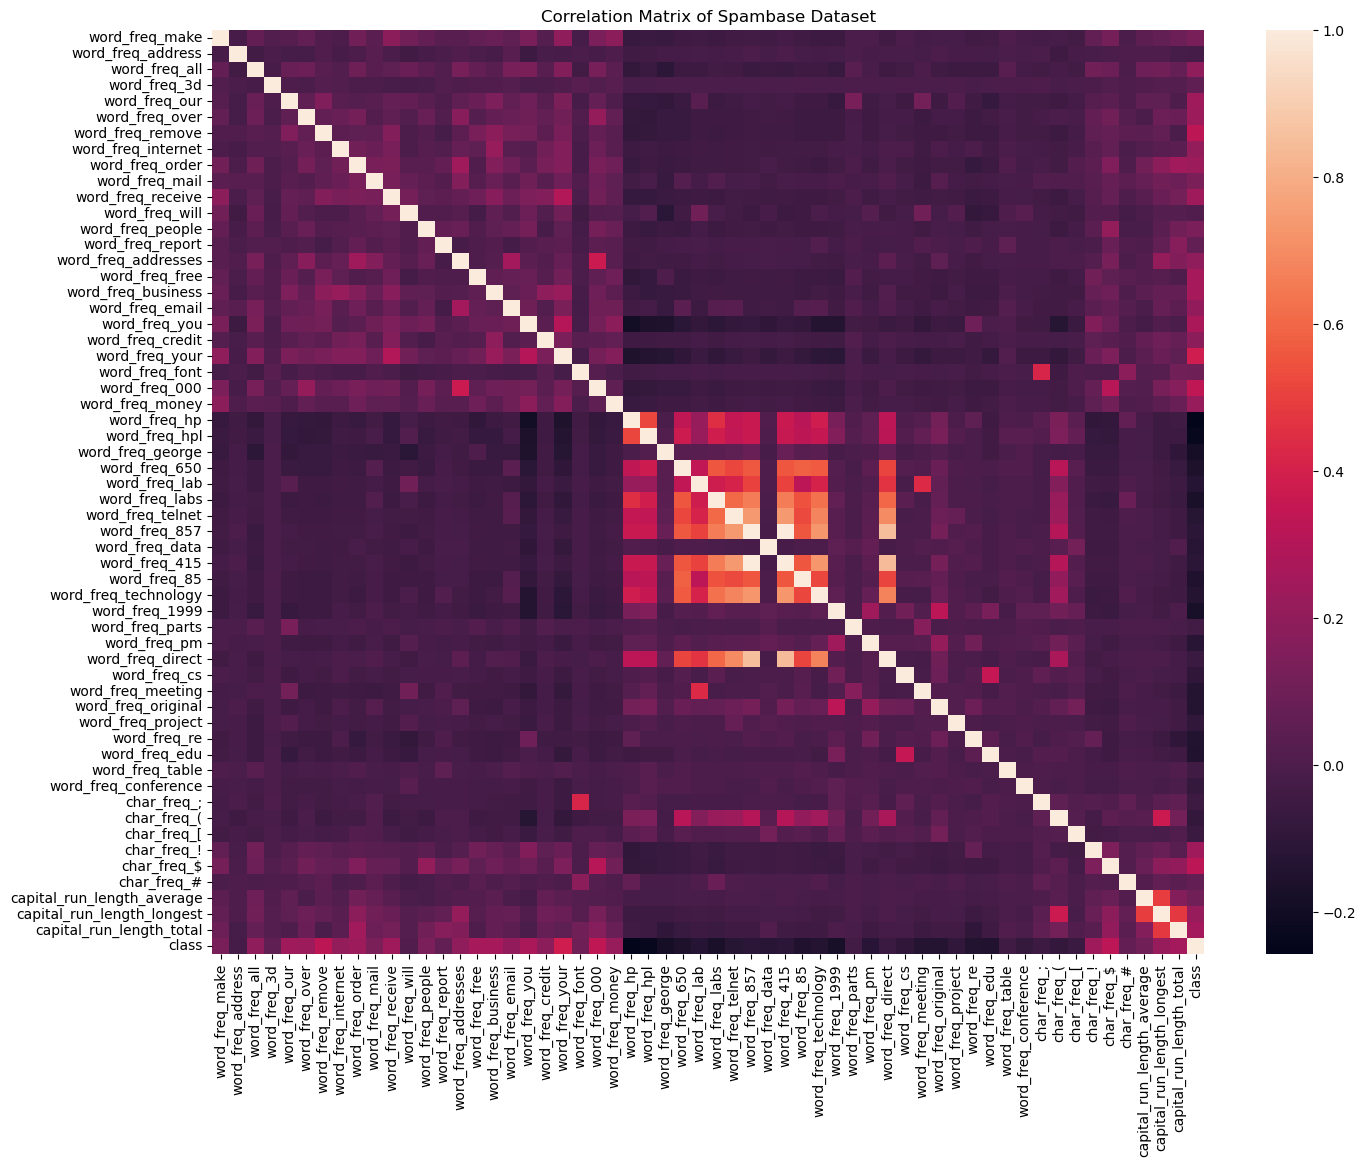

In [5]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix)
plt.title('Correlation Matrix of Spambase Dataset')
plt.show()

# Getting Informative features

In [6]:
# Set correlation threshold based on the 75th percentile
correlation_threshold = target_correlation.abs().quantile(0.75)
correlation_threshold

0.23155143128603217

In [23]:
informative_features = correlation_stats[(correlation_stats['Absolute Correlation (with Target variable)'] >= correlation_threshold)]
informative_features

,Feature,Correlation (with Target variable),Absolute Correlation (with Target variable)
4,word_freq_our,0.241920,0.241920
5,word_freq_over,0.232604,0.232604
6,word_freq_remove,0.332117,0.332117
8,word_freq_order,0.231551,0.231551
10,word_freq_receive,0.234529,0.234529
15,word_freq_free,0.263215,0.263215
16,word_freq_business,0.263204,0.263204
18,word_freq_you,0.273651,0.273651
20,word_freq_your,0.383234,0.383234
22,word_freq_000,0.334787,0.334787


In [7]:
non_informative_features = correlation_stats[(correlation_stats['Absolute Correlation (with Target variable)'] < correlation_threshold)]
non_informative_features

,Feature,Correlation (with Target variable),Absolute Correlation (with Target variable)
0,word_freq_make,0.126208,0.126208
1,word_freq_address,-0.030224,0.030224
2,word_freq_all,0.196988,0.196988
3,word_freq_3d,0.057371,0.057371
7,word_freq_internet,0.206808,0.206808
9,word_freq_mail,0.138962,0.138962
11,word_freq_will,0.007741,0.007741
12,word_freq_people,0.132927,0.132927
13,word_freq_report,0.060027,0.060027
14,word_freq_addresses,0.195902,0.195902


# Dividing the dataset into a training set and a test set

In [8]:
X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# DecisionTree Classifier (CART)

In [52]:
class DecisionTreeClassifier:
    """
        Initializes the DecisionTreeClassifier with an optional max_depth parameter.
        
        Parameters:
        - max_depth: The maximum depth of the tree. If None, the tree will grow until 
                     all leaves are pure or until no further splits can be made.
        - max_features: The number of features to consider when looking for the best split. 
                    If None, all features are considered. (used for RandomForestClassifier)
    """
    def __init__(self, max_depth=None,max_features=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.tree = None
    def fit(self, X, y):
        """
        Fits the decision tree classifier to the training data.
        
        Parameters:
        - X: Feature matrix (2D array-like).
        - y: Target vector (1D array-like).
        """
        self.tree = self.__build_tree(X, y, depth=0)
    
    def predict(self, X):
        """
        Predicts class labels for samples in X.
        
        Parameters:
        - X: Feature matrix (2D array-like).
        
        Returns:
        - List of predicted class labels.
        """
        return [self.__predict_sample(sample, self.tree) for sample in X]
    def visualize(self, feature_names):
        """
        Visualizes the decision tree using graphviz.
        
        Parameters:
        - feature_names: List of feature names for the visualization.
        
        Returns:
        - dot: A graphviz Digraph object representing the decision tree.
        """
        dot = graphviz.Digraph()
        self.__create_dot(dot, self.tree, feature_names)
        return dot
    def __build_tree(self, X, y, depth):
        """
        Recursively builds the decision tree.
        
        Parameters:
        - X: Feature matrix at the current node.
        - y: Target vector at the current node.
        - depth: Current depth of the tree.
        
        Returns:
        - A dictionary representing the node. Leaf nodes contain a 'label' key, 
          while decision nodes contain 'feature_index', 'threshold', 'left', and 'right' keys.
        """
        # If all class labels are the same or the max depth is reached, return a leaf node.
        if len(set(y)) == 1 or depth == self.max_depth:
            return {'label': np.bincount(y).argmax()}

        # Find the best split
        best_split = self.__find_best_split(X, y)
        if not best_split:
            return {'label': np.bincount(y).argmax()}

        # Recursively build left and right subtrees
        left_indices, right_indices = best_split['indices']
        left_node = self.__build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self.__build_tree(X[right_indices], y[right_indices], depth + 1)
        
        return {
            'feature_index': best_split['feature_index'],
            'threshold': best_split['threshold'],
            'left': left_node,
            'right': right_node
        }
    def __find_best_split(self, X, y):
        """
        Finds the best split for the data at the current node.
        
        Parameters:
        - X: Feature matrix at the current node.
        - y: Target vector at the current node.
        
        Returns:
        - A dictionary representing the best split, containing 'feature_index', 'threshold', 
          and 'indices' keys. Returns None if no valid split is found.
        """
        best_split = None
        min_gini = float('inf')
        
        if self.max_features is None:
            features = range(X.shape[1])
        else:
            features = np.random.choice(X.shape[1], self.max_features, replace=False)
        
        # Iterate through each feature
        for feature_index in features:
            thresholds, classes = zip(*sorted(zip(X[:, feature_index], y)))
            for i in range(1, len(y)):
                if thresholds[i] == thresholds[i - 1]:
                    continue
                # Find indices for left and right splits
                left_indices = np.where(X[:, feature_index] < thresholds[i])[0]
                right_indices = np.where(X[:, feature_index] >= thresholds[i])[0]
                # Calculate Gini impurity for the split
                gini = self.__weighted_average(y[left_indices], y[right_indices])
                if gini < min_gini:
                    min_gini = gini
                    best_split = {
                        'feature_index': feature_index,
                        'threshold': thresholds[i],
                        'indices': (left_indices, right_indices)
                    }
        return best_split
    
    def __predict_sample(self, sample, tree):
        """
        Predicts the class label for a single sample using the decision tree.
        
        Parameters:
        - sample: Feature vector of the sample.
        - tree: The decision tree.
        
        Returns:
        - Predicted class label.
        """
        if 'label' in tree:
            return tree['label']
        if sample[tree['feature_index']] < tree['threshold']:
            return self.__predict_sample(sample, tree['left'])
        else:
            return self.__predict_sample(sample, tree['right'])
    def __weighted_average(self,left_y,right_y):
        """
        Computes the weighted average of Gini impurities for the left and right splits.
        
        Parameters:
        - left_y: Target vector for the left split.
        - right_y: Target vector for the right split.
        
        Returns:
        - The weighted average Gini impurity.
        """
        left_size = len(left_y)
        right_size = len(right_y)
        total_size = left_size + right_size
        return (left_size / total_size) * self.__gini(left_y) + (right_size / total_size) * self.__gini(right_y)
    def __gini(self,y):
        """
        Computes the Gini impurity for a given target vector.
        
        Parameters:
        - y: Target vector.
        
        Returns:
        - Gini impurity.
        """
        return 1 - sum((np.sum(y == c) / len(y)) ** 2 for c in np.unique(y))
    
    def __create_dot(self, dot, node, feature_names, parent=None, edge_label=None):
        """
        Creates a graphviz dot representation of the decision tree.
        
        Parameters:
        - dot: A graphviz Digraph object.
        - node: The current node in the decision tree.
        - feature_names: List of feature names.
        - parent: The parent node ID in the graphviz Digraph.
        - edge_label: The label for the edge connecting the parent and current node.
        """
        # Create label for the current node
        if 'label' in node:
            label = f"Class: {node['label']}"
        else:
            label = f"{feature_names[node['feature_index']]} < {node['threshold']:.2f}"
        node_id = str(id(node))
        dot.node(node_id, label)
        # Add edge from parent to current node
        if parent is not None:
            dot.edge(parent, node_id, label=edge_label)
        # Recursively create dot for left and right children
        if 'left' in node:
            self.__create_dot(dot, node['left'], feature_names, node_id, 'yes')
        if 'right' in node:
            self.__create_dot(dot, node['right'], feature_names, node_id, 'no')

# Training

**Estimating best value for max-depth parameter using Cross-validation (including training errors)**

In [15]:
# Performing cross-validation and find the best max_depth, including training errors
best_max_depth = None
best_score = -float('inf')
max_depth_values = list(range(1, 21))
k=5

# KFold cross-validation
kf = KFold(n_splits=k, shuffle=True)
    
for max_depth in max_depth_values:
    test_scores = []
    train_errors = []
        
    for train_index, test_index in kf.split(X):
        X_train_, X_test_ = X[train_index], X[test_index]
        y_train_, y_test_ = y[train_index], y[test_index]
            
        # Initialize and train the classifier with the current max_depth
        spambaseTree = DecisionTreeClassifier(max_depth=max_depth)
        spambaseTree.fit(X_train_, y_train_)
            
        # Predict on the test set and calculate the accuracy
        y_test_pred_ = spambaseTree.predict(X_test_)
        test_score = accuracy_score(y_test_, y_test_pred_)
        test_scores.append(test_score)
            
        # Predict on the training set and calculate the error
        y_train_pred_ = spambaseTree.predict(X_train_)
        train_error = 1 - accuracy_score(y_train_, y_train_pred_)
        train_errors.append(train_error)
        
    # Calculate the average validation score and training error for the current max_depth
    avg_test_score = np.mean(test_scores)
    avg_train_error = np.mean(train_errors)
    print(f"Max Depth: {max_depth}  |  Avg Test Accuracy: {avg_test_score}  |  Avg Training Error: {avg_train_error}")
        
    # Update best_max_depth if the current one is better
    if avg_test_score > best_score:
        best_score = avg_test_score
        best_max_depth = max_depth

print(f"Best Score: {best_score}  |  Best Max Depth: {best_max_depth}")

Max Depth: 1  |  Avg Test Accuracy: 0.7828754189680404  |  Avg Training Error: 0.20522707676316693
Max Depth: 2  |  Avg Test Accuracy: 0.8365538403436718  |  Avg Training Error: 0.1486079958187166
Max Depth: 3  |  Avg Test Accuracy: 0.8826372562904217  |  Avg Training Error: 0.10872636216529061
Max Depth: 4  |  Avg Test Accuracy: 0.898718311853845  |  Avg Training Error: 0.0904148949363949
Max Depth: 5  |  Avg Test Accuracy: 0.9076299391021102  |  Avg Training Error: 0.0750924400269303
Max Depth: 6  |  Avg Test Accuracy: 0.9097993674172684  |  Avg Training Error: 0.06634391646882347
Max Depth: 7  |  Avg Test Accuracy: 0.9178463862531275  |  Avg Training Error: 0.05536854942536882
Max Depth: 8  |  Avg Test Accuracy: 0.9137140631638578  |  Avg Training Error: 0.04890232451011658
Max Depth: 9  |  Avg Test Accuracy: 0.9154524854836426  |  Avg Training Error: 0.03819828319336662
Max Depth: 10  |  Avg Test Accuracy: 0.9139290940848793  |  Avg Training Error: 0.035264224041198645
Max Depth: 1

In [16]:
# Initialize the DecisionTreeClassifier
spambaseTree = DecisionTreeClassifier(max_depth=best_max_depth)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaseTree.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 49.379688024520874


# Visualizing

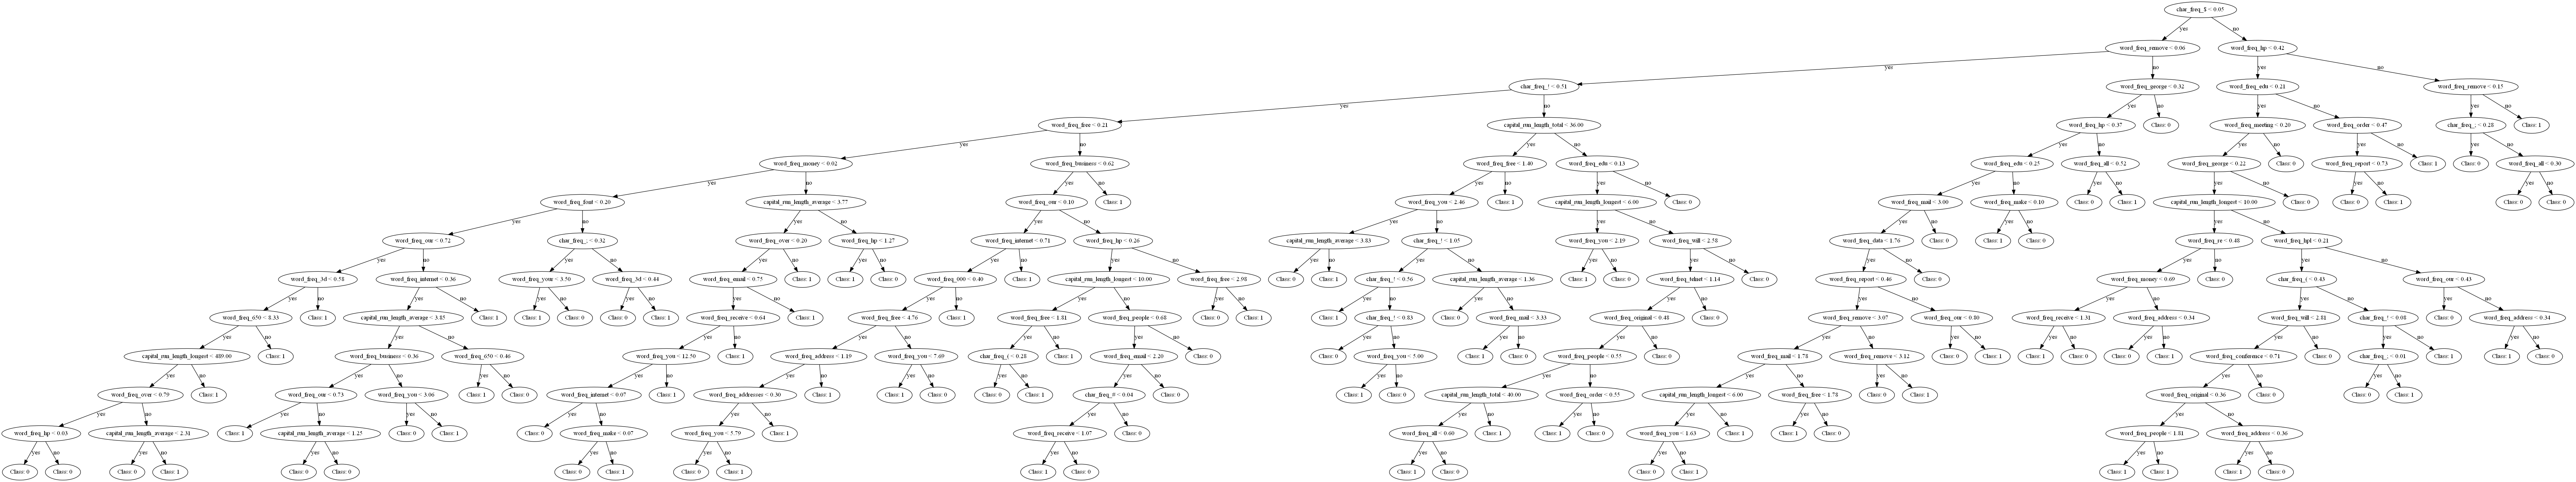

In [17]:
# Visualize the decision tree using the feature names (column_names)
dot = spambaseTree.visualize(column_names)
# Render the decision tree visualization as a PNG file and clean up the intermediate files
dot.render('spambaseTree', format='png', cleanup=True)
# Display the rendered decision tree image
Image("spambaseTree.png")

# Testing (Prediction)

In [18]:
start_time = time.time()
y_pred = spambaseTree.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.9275887038377987
Testing Time: 0.0099945068359375


# Training (without non-informative features)

In [45]:
# Initialize the DecisionTreeClassifier
spambaseTree = DecisionTreeClassifier(max_depth=best_max_depth)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaseTree.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 12.26612401008606


# Testing (without non-informative features)

In [47]:
start_time = time.time()
y_pred = spambaseTree.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.9116582186821144
Testing Time: 0.01099252700805664


**Conclusion**: the test accuracy tends to decline slightly. However, training and testing times become shorter.

# Random Forest

In [53]:
class RandomForestClassifier:
    def __init__(self, n_estimators, max_depth=None, max_features=None):
        """
        Initialize the RandomForestClassifier.
        
        Parameters:
        -----------
        n_estimators : int
            The number of trees in the forest.
        max_depth : int or None, optional (default=None)
            The maximum depth of the trees. If None, then nodes are expanded until all leaves are pure
            or until all leaves contain less than min_samples_split samples.
        max_features : int or None, optional (default=None)
            The number of features to consider when looking for the best split.
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = [DecisionTreeClassifier(max_depth=max_depth, max_features=max_features) for _ in range(n_estimators)]

    def fit(self, X, y):
        """
        Fit the RandomForestClassifier to the training data.
        
        Parameters:
        -----------
        X : numpy array, shape (n_samples, n_features)
            The input training samples.
        y : numpy array, shape (n_samples,)
            The target values.
        """
        for tree in self.trees:
            # Bootstrap sampling
            indices = np.random.choice(len(X), len(X), replace=True)
            bootstrap_X, bootstrap_y = X[indices], y[indices]
            # Train each tree on the bootstrap sample
            tree.fit(bootstrap_X, bootstrap_y)

    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : numpy array, shape (n_samples, n_features)
            The input samples to predict.
        
        Returns:
        --------
        y_pred : list
            Predicted class labels.
        """
        # Make predictions using each tree in the forest
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        # Combine predictions using majority voting
        y_pred = [Counter(tree_predictions[:, i]).most_common(1)[0][0] for i in range(len(X))]
        return y_pred

# Training

**Estimating best value for n_estimators and max-depth parameters using Cross-validation (including training errors)**

In [ ]:
# Performing cross-validation and find the best n_estimators and max-depth, including training errors
best_n_estimators = None
best_max_depth = None
best_score = -float('inf')
n_estimators_values = [10]
max_depth_values = [None,10,20]
k=5

# KFold cross-validation
kf = KFold(n_splits=k, shuffle=True)
    
for n in n_estimators_values:
    for max_depth in max_depth_values:
        test_scores = []
        train_errors = []
        
        for train_index, test_index in kf.split(X):
            X_train_, X_test_ = X[train_index], X[test_index]
            y_train_, y_test_ = y[train_index], y[test_index]
            
            # Initialize and train the classifier with the current n_estimators
            spambaseForest = RandomForestClassifier(n_estimators=n,max_depth=max_depth)
            spambaseForest.fit(X_train_, y_train_)
            
            # Predict on the test set and calculate the accuracy
            y_test_pred_ = spambaseForest.predict(X_test_)
            test_score = accuracy_score(y_test_, y_test_pred_)
            test_scores.append(test_score)
            
            # Predict on the training set and calculate the error
            y_train_pred_ = spambaseForest.predict(X_train_)
            train_error = 1 - accuracy_score(y_train_, y_train_pred_)
            train_errors.append(train_error)
        
        # Calculate the average validation score and training error for the current n_estimators
        avg_test_score = np.mean(test_scores)
        avg_train_error = np.mean(train_errors)
        print(f"n_estimators: {n}  |  Max Depth: {max_depth}  |  Avg Test Accuracy: {avg_test_score}  |  Avg Training Error: {avg_train_error}")
        
        # Update best_max_depth if the current one is better
        if avg_test_score > best_score:
            best_score = avg_test_score
            best_n_estimators = n
            best_max_depth = max_depth

print(f"Best Score: {best_score}  |  Best n_estimators: {best_n_estimators} | Best max_depth: {best_max_depth}")

In [64]:
# Initialize RandomForestClassifer
spambaseForest = RandomForestClassifier(n_estimators=best_n_estimators,max_depth=best_max_depth, max_features=7)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaseForest.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 35.90373969078064


# Testing (Prediction)

In [65]:
start_time = time.time()
y_pred = spambaseForest.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.944243301955105
Testing Time: 0.11193060874938965


# Training (without non-informative features)

In [67]:
# Initialize RandomForestClassifer
spambaseForest = RandomForestClassifier(n_estimators=best_n_estimators,max_depth=best_max_depth, max_features=7)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaseForest.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 48.415977478027344


# Testing (without non-informative features)

In [69]:
start_time = time.time()
y_pred = spambaseForest.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.9232440260680667
Testing Time: 0.11292815208435059


**Conclusion**: the test accuracy tends to decline slightly. However, training and testing times become shorter.

# Adaboost

In [32]:
class AdaBoostClassifier:
    def __init__(self, n_estimators):
        """
        Initialize the AdaBoostClassifier.
        
        Parameters:
        -----------
        n_estimators : int, optional (default=150)
            The number of weak learners (stumps) to train.
        
        Attributes:
        -----------
        n_estimators : int
            The number of weak learners (stumps) to train.
        alphas : list
            List to store the alpha values (weights) of the stumps.
        models : list
            List to store the trained decision stump models.
        """
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []

    def fit(self, X, y):
        """
        Fit the AdaBoostClassifier to the training data.
        
        Parameters:
        -----------
        X : numpy array, shape (n_samples, n_features)
            The input training samples.
        y : numpy array, shape (n_samples,)
            The target values (binary labels: 0 or 1).
        """
        n_samples, n_features = X.shape
        # Initialize weights
        w = np.ones(n_samples) / n_samples
        
        # Convert y from {0, 1} to {-1, +1}
        y_converted = np.where(y == 0, -1, 1)
        
        for _ in range(self.n_estimators):
            # Resampling based on weights
            sample_indices = np.random.choice(np.arange(n_samples), size=n_samples, p=w)
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]
            
            # Train a weak learner
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X_sample, y_sample)
            y_pred = stump.predict(X)
            y_pred_converted = np.where(y_pred == 0, -1, 1)

            # Calculate the total error
            err = np.sum(w * (y_pred != y))
            
            # Calculate the alpha value (amount of say of the stump)
            alpha = np.log((1 - err) / (err + 1e-100)) / 2
            self.alphas.append(alpha)
            self.models.append(stump)
            
            # Update weights
            w *= np.exp(-alpha * y_converted * y_pred_converted)
            w /= np.sum(w)  # Normalize weights
        
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : numpy array, shape (n_samples, n_features)
            The input samples to predict.
        
        Returns:
        --------
        y_pred : numpy array, shape (n_samples,)
            Predicted class labels (binary: 0 or 1).
        """
        # Initialize an array to store the weighted sum of predictions
        weighted_sum = np.zeros(X.shape[0])
        
        # Sum up the predictions from all models, weighted by their alpha
        for alpha, model in zip(self.alphas, self.models):
            y_pred = model.predict(X)
            weighted_sum += alpha * np.array(y_pred)
        
        y_pred_final = np.sign(weighted_sum)        
        return y_pred_final

# Training

**Estimating best value for n_estimators parameter using Cross-validation (including training errors)**

In [43]:
# Performing cross-validation and find the best n_estimators, including training errors
best_n_estimators = None
best_score = -float('inf')
n_estimators_values = [25,50,75,100,125,150,125,175,200]
k=5

# KFold cross-validation
kf = KFold(n_splits=k, shuffle=True)
    
for n in n_estimators_values:
    test_scores = []
    train_errors = []
        
    for train_index, test_index in kf.split(X):
        X_train_, X_test_ = X[train_index], X[test_index]
        y_train_, y_test_ = y[train_index], y[test_index]
            
        # Initialize and train the classifier with the current n_estimators
        spambaselclf = AdaBoostClassifier(n_estimators=n)
        spambaselclf.fit(X_train_, y_train_)
            
        # Predict on the test set and calculate the accuracy
        y_test_pred_ = spambaselclf.predict(X_test_)
        test_score = accuracy_score(y_test_, y_test_pred_)
        test_scores.append(test_score)
            
        # Predict on the training set and calculate the error
        y_train_pred_ = spambaselclf.predict(X_train_)
        train_error = 1 - accuracy_score(y_train_, y_train_pred_)
        train_errors.append(train_error)
        
    # Calculate the average validation score and training error for the current n_estimators
    avg_test_score = np.mean(test_scores)
    avg_train_error = np.mean(train_errors)
    print(f"n_estimators: {n}  |  Avg Test Accuracy: {avg_test_score}  |  Avg Training Error: {avg_train_error}")
        
    # Update best_n_estimators if the current one is better
    if avg_test_score > best_score:
        best_score = avg_test_score
        best_n_estimators = n

print(f"Best Score: {best_score}  |  Best n_estimators: {best_n_estimators}")

n_estimators: 25  |  Avg Test Accuracy: 0.8330729830524477  |  Avg Training Error: 0.1627897812503691
n_estimators: 50  |  Avg Test Accuracy: 0.7972197044800076  |  Avg Training Error: 0.18860115989275125
n_estimators: 75  |  Avg Test Accuracy: 0.8263447103809657  |  Avg Training Error: 0.1695833185689144
n_estimators: 100  |  Avg Test Accuracy: 0.8169964122173441  |  Avg Training Error: 0.18430805074235498
n_estimators: 125  |  Avg Test Accuracy: 0.7915668224519662  |  Avg Training Error: 0.19903225139671404
n_estimators: 150  |  Avg Test Accuracy: 0.8219886229523674  |  Avg Training Error: 0.17479760934528663
n_estimators: 125  |  Avg Test Accuracy: 0.8152480762875891  |  Avg Training Error: 0.1739819785502522
n_estimators: 175  |  Avg Test Accuracy: 0.818308313270075  |  Avg Training Error: 0.17414847690254304
n_estimators: 200  |  Avg Test Accuracy: 0.8328655053580702  |  Avg Training Error: 0.16295462598773963
Best Score: 0.8330729830524477  |  Best n_estimators: 25


In [44]:
# Initialize the AdaBoostClassifier
spambaselclf = AdaBoostClassifier(n_estimators=best_n_estimators)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 11.323928117752075


# Testing (Prediction)

In [42]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.8196958725561188
Testing Time: 0.021162748336791992


# Training (without non-informative features)

In [39]:
# Initialize the AdaBoostClassifier
spambaselclf = AdaBoostClassifier(n_estimators=best_n_estimators)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 2.940656900405884


# Testing (without non-informative features)

In [40]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.7936278059377263
Testing Time: 0.020985126495361328


**Conclusion**: the test accuracy tends to decline slightly. However, training and testing times become shorter.

We notice that in general, when we remove the non informative features and implement the algorithms with only the informative features, the test accuracy tends to decline slightly. However, training and testing times become shorter. Depending on which is more important to us, efficiency or accuracy, we can choose to use either of these methods.

# NaiveBayes

In [45]:
class NaiveBayesClassifier:
    def fit(self, X, y):
        """
        Fit the Naive Bayes classifier to the training data.
       
        Parameters:
        X (np.ndarray): Training feature set.
        y (np.ndarray): Training labels.
        """
        n_samples, n_features = X.shape
        self._classes = np.unique(y)  # Get unique class labels
        n_classes = len(self._classes)
       
        # Calculate mean, var, and prior for each class
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)  # Mean of each feature per class
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)  # Variance of each feature per class
        self._priors = np.zeros(n_classes, dtype=np.float64)  # Prior probabilities for each class
       
        for idx, c in enumerate(self._classes):
            X_c = X[y == c]  # Filter samples by class
            self._mean[idx, :] = X_c.mean(axis=0)  # Mean of features for class c
            self._var[idx, :] = X_c.var(axis=0)  # Variance of features for class c
            self._priors[idx] = X_c.shape[0] / float(n_samples)  # Prior probability of class c
   
    def predict(self, X):
        """
        Predict the class labels for the given test data.
       
        Parameters:
        X (np.ndarray): Test feature set.
       
        Returns:
        np.ndarray: Predicted class labels.
        """
        y_pred = [self.__predict_sample(x) for x in X]  # Predict class for each sample
        return np.array(y_pred)
   
    def __predict_sample(self, x):
        """
        Predict the class label for a single sample.
       
        Parameters:
        x (np.ndarray): Feature vector of a single sample.
       
        Returns:
        int: Predicted class label.
        """
        posteriors = []
       
        for idx, c in enumerate(self._classes):
            prior = self._priors[idx]  # Prior probability of class c
            posterior = reduce(lambda a, b: a * b, self._pdf(idx, x))  # Likelihood of x given class c
            posterior = prior * posterior  # Posterior probability of class c given x
            posteriors.append(posterior)
       
        return self._classes[np.argmax(posteriors)]  # Return class with highest posterior
    
    def _pdf(self, class_idx, x):
        '''
        Calculate the probability density function of the normal distribution.
       
        Parameters:
        class_idx (int): Index of the class.
        x (np.ndarray): Feature vector.
       
        Returns:
        np.ndarray: Probability density function value for each feature.
        '''
        mean = self._mean[class_idx]  # Mean of features for class class_idx
        var = self._var[class_idx]  # Variance of features for class class_idx
        numerator = np.exp(- (x - mean) ** 2 / (2 * (var+1e-5)))  # Numerator of normal PDF
        denominator = np.sqrt(2 * np.pi * (var+1e-5))  # Denominator of normal PDF
        return numerator / denominator  # normal PDF for each feature
            

# Training

In [46]:
# Initialize the NaiveBayesClassifier
spambaselclf = NaiveBayesClassifier()
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.0029997825622558594


# Testing (Prediction)

In [47]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.8233164373642288
Testing Time: 0.14790797233581543


# Training (without non-informative features)

In [48]:
# Initialize the NaiveBayesClassifier
spambaselclf = NaiveBayesClassifier()
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.0020003318786621094


# Testing (without non-informative features)

In [49]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.8638667632150615
Testing Time: 0.11792850494384766


**Conclusion**: It seems that in this algorithm, non-inforamtive features may cause overfitting in our model. So by removing these features, accuracy increased and training and testing times becomes shorter.

# Logistic Regression

In [33]:
class LogisticRegressionsClassifier:
    def __init__(self, learning_rate, num_iterations=1000):
        """
        Initialize the LogisticRegression model with learning rate and number of iterations.
       
        Parameters:
        learning_rate (float): Learning rate for gradient descent.
        num_iterations (int): Number of iterations for gradient descent.
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None

    def fit(self, X, y):
        """
        Fit the logistic regression model to the training data.
       
        Parameters:
        X (np.ndarray): Training feature set.
        y (np.ndarray): Training labels.
        """
        self.weights = np.zeros(X.shape[1])
        cost_history = []
        for _ in range(self.num_iterations):
            h = self.__sigmoid(np.dot(X, self.weights))
            gradient = np.dot(X.T, (h - y)) / len(y)
            self.weights -= self.learning_rate * gradient
            cost = self.__cost_function(X, y, self.weights)
            cost_history.append(cost)
    
    def predict(self, X):
        """
        Predict class labels for the given test data.
       
        Parameters:
        X (np.ndarray): Test feature set.
       
        Returns:
        np.ndarray: Predicted class labels.
        """
        return self.__sigmoid(np.dot(X, self.weights)) >= 0.5
    
    def __cost_function(self, X, y, weights):
        """
        Compute the cost function for logistic regression.
       
        Parameters:
        X (np.ndarray): Feature set.
        y (np.ndarray): Labels.
        weights (np.ndarray): Weights for logistic regression.
       
        Returns:
        float: Cost function value.
        """
        m = len(y)
        h = self.__sigmoid(np.dot(X, weights))
        epsilon = 1e-9
        cost = (-1/m) * (np.dot(y, np.log(h + epsilon)) + np.dot((1 - y), np.log(1 - h + epsilon)))
        return cost
    def __sigmoid(self, z):
        """
        Compute the sigmoid function.
       
        Parameters:
        z (np.ndarray): Input array.
       
        Returns:
        np.ndarray: Sigmoid of the input.
        """
        return expit(z)


# Training

**Estimating best value for learning_rate parameter using Cross-validation (including training errors)**

In [39]:
# Performing cross-validation and find the best learning_rate, including training errors
best_learning_rate = None
best_score = -float('inf')
learning_rate_values = [0.01,0.1,1,5]
k=5

# KFold cross-validation
kf = KFold(n_splits=k, shuffle=True)
    
for n in learning_rate_values:
    test_scores = []
    train_errors = []
        
    for train_index, test_index in kf.split(X):
        X_train_, X_test_ = X[train_index], X[test_index]
        y_train_, y_test_ = y[train_index], y[test_index]
            
        # Initialize and train the classifier with the current learning_rate
        spambaselclf = LogisticRegressionsClassifier(learning_rate=n)
        spambaselclf.fit(X_train_, y_train_)
            
        # Predict on the test set and calculate the accuracy
        y_test_pred_ = spambaselclf.predict(X_test_)
        test_score = accuracy_score(y_test_, y_test_pred_)
        test_scores.append(test_score)
            
        # Predict on the training set and calculate the error
        y_train_pred_ = spambaselclf.predict(X_train_)
        train_error = 1 - accuracy_score(y_train_, y_train_pred_)
        train_errors.append(train_error)
        
    # Calculate the average validation score and training error for the current learning_rate
    avg_test_score = np.mean(test_scores)
    avg_train_error = np.mean(train_errors)
    print(f"learning_rate: {n}  |  Avg Test Accuracy: {avg_test_score}  |  Avg Training Error: {avg_train_error}")
        
    # Update best_learning_rate if the current one is better
    if avg_test_score > best_score:
        best_score = avg_test_score
        best_learning_rate = n

print(f"Best Score: {best_score}  |  Best learning_rate: {best_learning_rate}")

learning_rate: 0.01  |  Avg Test Accuracy: 0.5425086153991407  |  Avg Training Error: 0.4533302328053577
learning_rate: 0.1  |  Avg Test Accuracy: 0.649647358731058  |  Avg Training Error: 0.35095722157258774
learning_rate: 1  |  Avg Test Accuracy: 0.5841901524807629  |  Avg Training Error: 0.42120555909901614
learning_rate: 5  |  Avg Test Accuracy: 0.5263857810508427  |  Avg Training Error: 0.47179420171739733
Best Score: 0.649647358731058  |  Best learning_rate: 0.1


# Training

In [40]:
# Initialize the LogisticRegressionsClassifier
spambaselclf = LogisticRegressionsClassifier(learning_rate=best_learning_rate)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.8025045394897461


# Testing (Prediction)

In [41]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.6799420709630702
Testing Time: 0.0009982585906982422


# Training (without non-informative features)

In [42]:
# Initialize the LogisticRegressionsClassifier
spambaselclf = LogisticRegressionsClassifier(learning_rate=best_learning_rate)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.6775791645050049


# Testing (without non-informative features)

In [43]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.4373642288196959
Testing Time: 0.0010004043579101562


# LinearSVM

In [18]:
class LinearSVMClassifier:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, num_iterations=1000):
        '''
        Initialize the Linear SVM model with learning rate, regularization parameter, and number of iterations.

        Parameters:
        learning_rate (float): Learning rate for gradient descent.
        lambda_param (float): Regularization parameter.
        num_iterations (int): Number of iterations for gradient descent.
        '''
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.num_iterations = num_iterations

    def fit(self, X, y):
        '''
        Fit the Linear SVM model to the training data.

        Parameters:
        X (np.ndarray): Training feature set.
        y (np.ndarray): Training labels.
        '''
        y_converted = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.num_iterations):
            for idx, x_i in enumerate(X):
                condition = y_converted[idx] * (np.dot(x_i, self.weights) - self.bias) >= 1
                if condition:
                    self.weights -= self.learning_rate * (2 * self.lambda_param * self.weights)
                else:
                    self.weights -= self.learning_rate * (2 * self.lambda_param * self.weights - np.dot(x_i, y_converted[idx]))
                    self.bias -= self.learning_rate * y_converted[idx]

    def predict(self, X):
        '''
        Predict class labels for the given test data.

        Parameters:
        X (np.ndarray): Test feature set.

        Returns:
        np.ndarray: Predicted class labels.
        '''
        approx = np.dot(X, self.weights) - self.bias
        return np.sign(approx)

# Training

In [19]:
# Initialize the LinearSVMClassifier
spambaselclf = LinearSVMClassifier()
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 56.342100858688354


# Testing (Prediction)

In [20]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
y_pred = np.where(y_pred == -1, -0, 1)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.6039102099927589
Testing Time: 0.0009999275207519531


# Training (without non-informative features)

In [24]:
# Initialize the LinearSVMClassifier
spambaselclf = LinearSVMClassifier()
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 55.289756059646606


# Testing (without non-informative features)

In [25]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
y_pred = np.where(y_pred == -1, -0, 1)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.5763939174511223
Testing Time: 0.0010001659393310547


# KNN

In [71]:
class KNNClassifier:
    def __init__(self, k=3):
        """
        Initialize the k-NN classifier with the specified number of neighbors (k).
        """
        self.k = k

    def fit(self, X, y):
        """
        Store the training data.
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """
        Predict the class labels for the provided data.
        """
        predictions = [self.__predict(x) for x in X]
        return np.array(predictions)

    def __predict(self, x):
        """
        Predict the class label for a single data point.
        """
        # Compute the distances between x and all examples in the training set
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
        # Sort by distance and return the indices of the first k neighbors
        k_indices = np.argsort(distances)[:self.k]
        # Extract the labels of the k nearest neighbor training samples
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # Return the most common class label
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

# Training

In [ ]:
# Performing cross-validation and find the best k, including training errors
best_k = None
best_score = -float('inf')
k_values = [3,5,7,10]
k=5

# KFold cross-validation
kf = KFold(n_splits=k, shuffle=True)
    
for k_value in k_values:
    test_scores = []
    train_errors = []
        
    for train_index, test_index in kf.split(X):
        X_train_, X_test_ = X[train_index], X[test_index]
        y_train_, y_test_ = y[train_index], y[test_index]
            
        # Initialize and train the classifier with the current k
        spambaselclf = KNNClassifier(k=k_value)
        spambaselclf.fit(X_train_, y_train_)
            
        # Predict on the test set and calculate the accuracy
        y_test_pred_ = spambaselclf.predict(X_test_)
        test_score = accuracy_score(y_test_, y_test_pred_)
        test_scores.append(test_score)
            
        # Predict on the training set and calculate the error
        y_train_pred_ = spambaselclf.predict(X_train_)
        train_error = 1 - accuracy_score(y_train_, y_train_pred_)
        train_errors.append(train_error)
        
    # Calculate the average validation score and training error for the current k
    avg_test_score = np.mean(test_scores)
    avg_train_error = np.mean(train_errors)
    print(f"k: {k_value}  |  Avg Test Accuracy: {avg_test_score}  |  Avg Training Error: {avg_train_error}")
        
    # Update best_max_depth if the current one is better
    if avg_test_score > best_score:
        best_score = avg_test_score
        best_k = k_value

print(f"Best Score: {best_score}  |  Best k: {best_k}")

In [76]:
# Initialize the KNNClassifier
spambaselclf = KNNClassifier(k=best_k)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.0


# Testing (Prediction)

In [77]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.7646632874728457
Testing Time: 44.363492012023926


# Training (without non-informative features)

In [80]:
# Initialize the KNNClassifier
spambaselclf = KNNClassifier(k=best_k)
# Fit the classifier to the training data (X_train and y_train)
start_time = time.time()
spambaselclf.fit(X_train[:,informative_features.index], y_train)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training Time: {elapsed_time}")

Training Time: 0.0019998550415039062


# Testing (without non-informative features)

In [81]:
start_time = time.time()
y_pred = spambaselclf.predict(X_test[:,informative_features.index])
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Testing Time: {elapsed_time}")

Accuracy: 0.7538015930485156
Testing Time: 44.0169095993042


# Comparison of Algorithms

\begin{array}{|c|c|c|}
\hline
\text{} & \text{Training Time} & \text{Testing Time} & \text{Accuracy} \\
\hline
\text{DecisionTree(CART)} & 49.37s & 0.009s & 92\% \\
\hline
\text{RandomForest} & 35.9s & 0.11s & 94\% \\
\hline
\text{Adaboost} & 11.32s & 0.02s & 81\% \\
\hline
\text{Naive Bayes} & 0.002s & 0.14s & 82\% \\
\hline
\text{Logistic Regression} & 0.80s & 0.00s & 67\% \\
\hline
\text{LinearSVM} & 56.34s & 0.0009s & 60\% \\
\hline
\hline
\text{KNN} & 0s & 44.36s & 76\% \\
\hline
\end{array}

 # Comparison of Algorithm (without non-informative features)

\begin{array}{|c|c|c|}
\hline
\text{} & \text{Training Time} & \text{Testing Time} & \text{Accuracy} \\
\hline
\text{DecisionTree(CART)} & 12.26s & 0.01s & 91\% \\
\hline
\text{RandomForest} & 48.41s & 0.11s & 92\% \\
\hline
\text{Adaboost} & 2.94s & 0.02s & 79\% \\
\hline
\text{Naive Bayes} & 0.002s & 0.11s & 86\% \\
\hline
\text{Logistic Regression} & 0.67s & 0.001s & 43\% \\
\hline
\text{LinearSVM} & 55.28s & 0.001s & 57\% \\
\hline
\hline
\text{KNN} & 0s & 44.016s & 75\% \\
\hline
\end{array}